This is the file containing the refined SNN model from scratch as well as data extraction, training, precition, and benchmarking with PyTorch version

# Imports

In [8]:
import numpy as np # numpy is the computational backbone
import matplotlib.pyplot as plt # for demonstration of components of the project
import ast # for string to list used to get the training and testing data
import random as rand # for random sampling of training data

# Data Processing

In [9]:
# Data import
X_data = []
y_data = []

with open("snn_training_data.txt", "r", encoding="utf-8") as file:
    for line in file:
        x_s, y_s = line.strip().split("] [")
        x_s += "]"
        y_s = "[" + y_s

        X_data.append(ast.literal_eval(x_s))
        y_data.append(ast.literal_eval(y_s))

print(X_data)
print(y_data)

[[[0, 0, 1], [0, 0, 0], [0, 0, 1], [0, 0, 0], [0, 0, 0], [0, 1, 0], [1, 1, 0], [0, 1, 1], [1, 0, 0], [1, 0, 0]], [[1, 0, 1], [1, 1, 0], [1, 0, 1], [0, 1, 1], [0, 0, 0], [0, 1, 0], [0, 0, 1], [1, 1, 1], [0, 1, 1], [0, 1, 0]], [[0, 0, 0], [1, 1, 1], [0, 1, 0], [0, 0, 1], [1, 1, 0], [0, 1, 0], [1, 1, 1], [0, 1, 0], [0, 1, 1], [1, 1, 0]], [[0, 1, 0], [0, 0, 0], [0, 1, 0], [1, 1, 1], [1, 0, 0], [1, 1, 0], [1, 1, 0], [1, 0, 1], [0, 0, 1], [0, 0, 1]], [[0, 0, 1], [1, 0, 0], [1, 1, 0], [0, 0, 0], [0, 1, 0], [0, 0, 1], [0, 1, 1], [0, 0, 1], [1, 1, 1], [1, 0, 0]], [[0, 0, 1], [0, 0, 0], [0, 0, 0], [0, 0, 0], [1, 0, 0], [1, 1, 0], [0, 1, 0], [1, 1, 0], [0, 0, 1], [1, 1, 1]], [[1, 0, 0], [0, 1, 1], [0, 0, 0], [0, 1, 0], [1, 0, 1], [1, 0, 0], [1, 0, 0], [0, 0, 0], [0, 1, 1], [1, 0, 1]], [[0, 0, 1], [0, 1, 1], [1, 1, 1], [1, 0, 0], [1, 0, 0], [0, 1, 0], [0, 1, 0], [0, 0, 0], [0, 0, 0], [1, 0, 0]], [[0, 0, 1], [1, 1, 0], [1, 0, 1], [1, 0, 1], [1, 1, 0], [0, 1, 0], [0, 0, 1], [0, 1, 0], [0, 1, 1], [0,

[[0, 0, 1], [0, 0, 0], [0, 0, 1], [0, 0, 0], [0, 0, 0], [0, 1, 0], [1, 1, 0], [0, 1, 1], [1, 0, 0], [1, 0, 0]] [1, 0, 0]


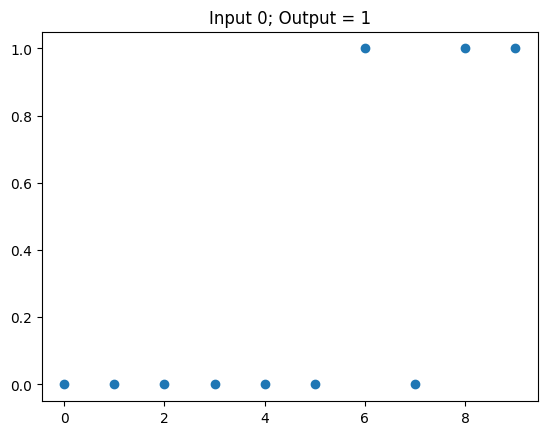

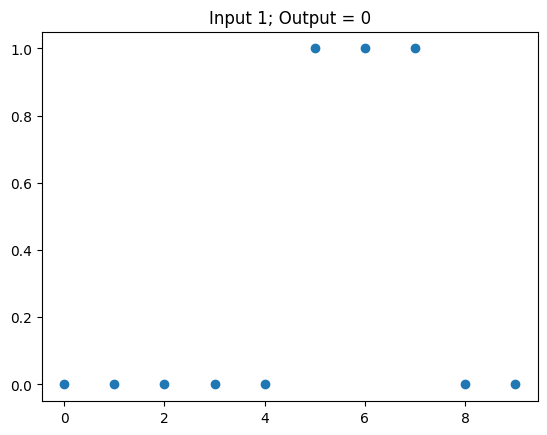

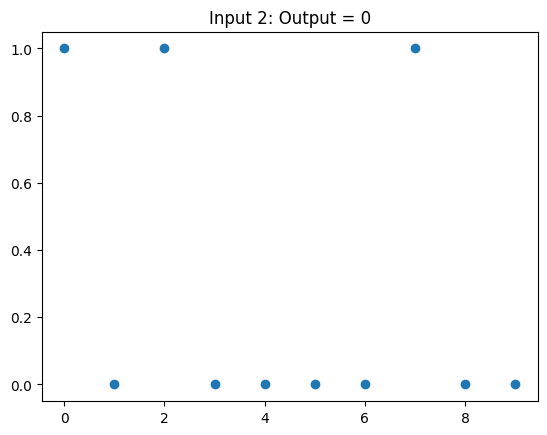

In [10]:
# Visualize a single input
vis_x = X_data[0]
vis_y = y_data[0]

print(vis_x, vis_y)

plt_x = np.arange(0,len(vis_x),1)

time_series_0 = []
time_series_1 = []
time_series_2 = []

for i in range(len(vis_x)):
    time_series_0.append(vis_x[i][0])
    time_series_1.append(vis_x[i][1])
    time_series_2.append(vis_x[i][2])

plt.scatter(plt_x, time_series_0)
plt.title("Input 0; Output = 1")
plt.show()

plt.scatter(plt_x, time_series_1)
plt.title("Input 1; Output = 0")
plt.show()

plt.scatter(plt_x, time_series_2)
plt.title("Input 2: Output = 0")
plt.show()


In [11]:
# Splitting data
# 80/20 train/test split

X_train = []
X_test = []
y_train = []
y_test = []

X_data_cpy = X_data.copy()
y_data_cpy = y_data.copy()

for i in range(80):
    randVal = rand.randrange(0,len(X_data_cpy))
    X_train.append(X_data_cpy[randVal])
    y_train.append(y_data_cpy[randVal])

    X_data_cpy.pop(randVal)
    y_data_cpy.pop(randVal)

X_test = X_data_cpy
y_test = y_data_cpy

print("Trainig Data")
print(len(X_train), len(y_train))
print(X_train, y_train)

print("Testing Data")
print(len(X_test), len(y_test))
print(X_test, y_test)


Trainig Data
80 80
[[[1, 0, 1], [0, 0, 0], [0, 1, 0], [1, 0, 0], [1, 0, 1], [1, 1, 0], [1, 1, 1], [0, 0, 0], [1, 0, 0], [1, 1, 0]], [[0, 0, 0], [0, 1, 0], [1, 0, 0], [1, 0, 0], [1, 0, 0], [1, 1, 1], [0, 1, 0], [0, 1, 1], [0, 0, 1], [1, 1, 0]], [[1, 0, 1], [0, 0, 1], [1, 1, 0], [0, 0, 0], [1, 1, 1], [0, 1, 1], [1, 1, 0], [0, 1, 0], [1, 0, 0], [1, 1, 1]], [[1, 1, 0], [0, 0, 0], [1, 0, 1], [0, 1, 1], [0, 1, 1], [0, 0, 1], [0, 0, 0], [0, 0, 1], [0, 1, 1], [1, 0, 0]], [[1, 1, 1], [0, 0, 0], [0, 1, 1], [1, 0, 0], [0, 0, 1], [1, 0, 0], [1, 0, 0], [1, 0, 0], [0, 1, 0], [1, 0, 0]], [[1, 1, 0], [1, 1, 1], [0, 0, 0], [1, 1, 1], [1, 0, 0], [1, 0, 0], [0, 0, 1], [1, 1, 0], [0, 1, 1], [0, 1, 1]], [[0, 0, 0], [0, 0, 1], [1, 0, 1], [1, 1, 1], [0, 0, 1], [0, 1, 0], [0, 0, 0], [1, 0, 1], [1, 0, 1], [1, 1, 1]], [[1, 0, 1], [0, 1, 0], [0, 1, 1], [1, 1, 0], [0, 0, 1], [0, 0, 0], [0, 0, 1], [1, 1, 1], [0, 1, 1], [1, 0, 0]], [[1, 0, 1], [1, 1, 0], [1, 1, 1], [0, 1, 0], [0, 1, 0], [0, 1, 0], [1, 0, 0], [1, 1,

# Spiking Neural Network Classes

In [41]:
# Spiking Neuron Model
# Define inputs, weights for inputs, decay constant, firing threshold

class Spike_neuron():
    def __init__(self, weights, decay_c, fire_thresh, cooldown_thresh):
        self.potential = 0                      # Current Potential in the Neuron Body
        self.weights = weights                  # Weights for each input from previous layer
        self.decay_c = decay_c                  # Decay constant which represents how fast the potential drops back to resting
        self.fire_thresh = fire_thresh          # Threshold at which the neuron fires to the next neurons in the next layer
        self.output = 0                         # Output signal of this neuron(firing signal)
        self.cooldown_thresh = cooldown_thresh  # Cooldown timer, usually brain neurons after firing have a set period for which they cannot fire
        self.counter = 0                        # The counter to enforce this timing delay between subsequent spikes
        self.spike_input_corr = np.zeros(3)
    
    def accumulate(self, inputs):
        self.output = 0
        # If the neuron is in resting state(cooldown) then no inputs are recieved
        # If the neuron is accepting inputs then it is is the matrix product of the inputs with the weights to obtain a single value which is added and checked with potential
        # If the potential is high enough then se fire for this neuron
        if self.counter > 0:
            self.output = 0
            self.counter -= 1
        else:
            potential_gain = self.weights @ inputs.T
            self.potential += potential_gain
            if(self.potential >= self.fire_thresh):
                self.spike_input_corr += inputs[0]
                self.fire()
        self.decay()
    
    def decay(self):
        # At each time step, the neuron is constantly losing potential and returning to resting potential(0)
        self.potential = self.potential - self.decay_c * self.potential
    
    def fire(self):
        # Firing involves setting the output to 1, setting potential back to 0, and setting a counter for cooldown
        self.output = 1
        self.potential = np.array([0])
        self.counter = self.cooldown_thresh

    def reset_state(self):
        self.potential = 0
        self.output = 0
        self.counter = 0
        self.spike_input_corr = np.zeros(3)

In [13]:
class Spike_Layer():
    def __init__(self, num_neuron, weights_v, decay_c_v, fire_thresh_v, cooldown_thresh_v):
        self.num_neuron = num_neuron
        self.weights_v = weights_v
        self.decay_c_v = decay_c_v
        self.fire_thresh_v = fire_thresh_v
        self.cooldown_thresh_v = cooldown_thresh_v
        self.neuron_list = []

    def initialize_neurons(self):
        for i in range(self.num_neuron):
            self.neuron_list.append(Spike_neuron(self.weights_v[i], self.decay_c_v[i], self.fire_thresh_v[i], self.cooldown_thresh_v[i]))

    def signal_prop(self, input_v):
        for i in range(len(self.neuron_list)):
            self.neuron_list[i].accumulate(np.array([input_v[0]]))


In [30]:
class Spike_Prop_Layer():
    # This layer is the interconnection between SNN neuron layers which collects output from one layer and feeds it as inputs to the next
    def __init__(self, l1, l2):
        self.Layer_in = l1
        self.Layer_out = l2
        self.spike_prop = []
        self.freq_count = np.zeros(l1.num_neuron)
        self.percentage_spikes = np.zeros(l1.num_neuron)
        self.threshold_correction_v = np.zeros(l1.num_neuron)

    def output_collect(self):
        # Logic for collecting the output signals
        self.spike_prop = np.zeros(len(l1.neuron_list))
        for i in range(len(l1.neuron_list)):
            self.spike_prop[i] = l1.neuron_list[i].output
        return self.spike_prop
    
    def log_output_spike(self):
            for i in range(len(self.spike_prop)):
                self.freq_count[i] += self.spike_prop[i]

    def compute_percentage_spikes(self):
            total_spike = 0
            for i in range(len(self.freq_count)):
                total_spike += self.freq_count[i]
            if(total_spike != 0):
                for i in range(len(self.percentage_spikes)):
                    self.percentage_spikes[i] = self.freq_count[i]/total_spike
            else:
                 self.percentage_spikes = np.zeros(self.Layer_in.num_neuron)
    

In [28]:
class Output_Decision_Layer():
    def __init__(self, output_layer):
        self.output_layer = output_layer
        self.output_count = np.zeros(output_layer.num_neuron)
        self.percentage_spike = np.zeros(output_layer.num_neuron)

    def log_output_spike(self):
        for i in range(len(self.output_count)):
            self.output_count[i] += self.output_layer.neuron_list[i].output

    def predict_output(self):
        output = 0
        output_count = 0
        for i in range(len(self.output_count)):
            if(self.output_count[i] > output_count):
                output = i
                output_count = self.output_count[i]
        return output

    def compute_percentage_spikes(self):
        total_spike = 0
        for i in range(len(self.output_count)):
            total_spike += self.output_count[i]
        if(total_spike != 0):
            for i in range(len(self.percentage_spike)):
                self.percentage_spike[i] = self.output_count[i]/total_spike
        else:
            self.percentage_spike = np.zeros(self.output_layer.num_neuron)

In [39]:
def Training_Changes(connect_layers, output_layer, y):

    # Based on frequency of spikes(since we want the hidden layer neurons to be active, but also one should not be dominating)
    # We can train by basically deciding a range we want to keep activity of each neuron in(0.3-0.5) and then add a correction factor which has a sign based on how far away from this we are to change the thresholds
    # When we do tune the parameters, we need to multiply this correction factor by some alpha to get the actual change to the threshold
    for layer in connect_layers:
        print(f'percentage spike: {layer.percentage_spikes}')

        for i in range(len(layer.percentage_spikes)):
            if(layer.percentage_spikes[i] < 0.1):
                layer.threshold_correction_v[i] = 0.2 - layer.percentage_spikes[i]
            elif(layer.percentage_spikes[i] > 0.8):
                layer.threshold_correction_v[i] = 0.7 - layer.percentage_spikes[i]
            else:
                layer.threshold_correction_v[i] = 0

        layer.Layer_in.fire_thresh_v = layer.Layer_in.fire_thresh_v - layer.threshold_correction_v * 3

        for i in range(len(layer.Layer_in.neuron_list)):
            layer.Layer_in.neuron_list[i].fire_thresh = layer.Layer_in.fire_thresh_v[i]
    # - If so we increase the weight if not we decrease it, we can perform this for all of them and average the result because each neuron in a layer is connected to the others, but the individual weights also play into this
    # 4) Depending on if we made a right or wrong connection then we can update this fact, if we are correct, keep the values, if not then invert them and repeat this for all training examples so we converge to the average where we predict as best as possible
    # -> We need to calculate if we are right or wrong and by how much and that affects the direction of the changes
    # --> Creating a variable for measuring the direction and magnitude of the correct diagnosis(define a variable for the actual output, 1 for correct, 0 for wrong and then in the decision layer keep that value(we would then need to return this value and pass it in through the training conversion play))
    
    # Find the true class from the perfect(true) labelled solution vector
    true_class = -1
    print(f'y {y} {len(y)}')
    for i in range(len(y)):
        if y[i] == 1:
            true_class = i
            break
    print(f'true_class {true_class}')
    # compute the loss as what is the deviation from how much we predicted the true class
    loss = 1-output_layer.percentage_spike[true_class]
    print(f'output_layer.percentage_spike[true_class] = {output_layer.percentage_spike[true_class]}')
    print(F'loss {loss}')

    target = np.asarray(y, dtype=float)
    rates = np.asarray(output_layer.percentage_spike, dtype=float)
    hidden_activity = np.asarray(connect_layers[0].freq_count, dtype=float)
    learning_rate = 0.01

    class_err_v = []

    output_weights_before_update = np.stack([
        np.asarray(neuron.weights, dtype=float)
        for neuron in output_layer.output_layer.neuron_list
    ])

    for class_index, neuron in enumerate(output_layer.output_layer.neuron_list):
        neuron.weights = np.asarray(neuron.weights, dtype=float)
        class_error = target[class_index] - rates[class_index] # finds error rate from percentages depending on the actual one hot encoding
        class_err_v.append(class_error)
        neuron.weights += learning_rate * class_error * hidden_activity

    class_errors = np.asarray(class_err_v, dtype=float)
    # for hidden layer neurons we look at what input lead to the spikes most frequently based on percentage and then inc/dec(or don't touch) weight based on that
    for hidden_index, neuron in enumerate(connect_layers[0].Layer_in.neuron_list):
        neuron.weights = np.asarray(neuron.weights, dtype=float)

        # Combine this hidden neuron's outgoing weights with all class errors.
        outgoing_weights = output_weights_before_update[:, hidden_index]
        hidden_credit = np.dot(outgoing_weights, class_errors)

        feature_activity = np.asarray(neuron.spike_input_corr, dtype=float)
        total_activity = feature_activity.sum()

        if total_activity > 0:
            feature_activity /= total_activity
            neuron.weights += learning_rate * hidden_credit * feature_activity

    return loss

# SNN Network Implementation
**Input -> 3 Hidden Neurons -> 3 Output Neurons**

1 0
[0. 2. 0.]
percentage spike: [0.33333333 0.5        0.16666667]
y [1, 0, 0] 3
true_class 0
output_layer.percentage_spike[true_class] = 0.0
loss 1.0
1 0
[0. 1. 0.]
percentage spike: [0.4 0.4 0.2]
y [1, 0, 0] 3
true_class 0
output_layer.percentage_spike[true_class] = 0.0
loss 1.0
1 0
[0. 2. 0.]
percentage spike: [0.33333333 0.44444444 0.22222222]
y [1, 0, 0] 3
true_class 0
output_layer.percentage_spike[true_class] = 0.0
loss 1.0
1 2
[0. 1. 0.]
percentage spike: [0.33333333 0.5        0.16666667]
y [0, 0, 1] 3
true_class 2
output_layer.percentage_spike[true_class] = 0.0
loss 1.0
1 0
[0. 1. 0.]
percentage spike: [0.33333333 0.5        0.16666667]
y [1, 0, 0] 3
true_class 0
output_layer.percentage_spike[true_class] = 0.0
loss 1.0
1 0
[0. 2. 0.]
percentage spike: [0.375 0.375 0.25 ]
y [1, 0, 0] 3
true_class 0
output_layer.percentage_spike[true_class] = 0.0
loss 1.0
1 2
[0. 2. 0.]
percentage spike: [0.28571429 0.42857143 0.28571429]
y [0, 0, 1] 3
true_class 2
output_layer.percentage_spike

'\nFix the zero-spike branch in the hidden connection layer. Its new fallback refers to self.l1, but the class stores the input layer as self.Layer_in. When there are no hidden spikes, that branch will raise AttributeError. Use the stored layer reference there. Also, output_collect() uses the global l1 rather than the instance’s input layer; use the instance reference so this class behaves correctly outside this specific notebook setup.\n\nKeep accuracy separate from loss. Your print now compares the predicted class to argmax(y_train[l]), which is the right comparison. Record whether that comparison is correct for each sample and report accuracy by epoch. Keep the spike-share value labeled as a diagnostic unless you replace it with a defined training objective. For ties or no output spikes, decide explicitly whether prediction should be “no prediction” or a deterministic fallback; currently predict_output() silently returns class 0.\n\n'

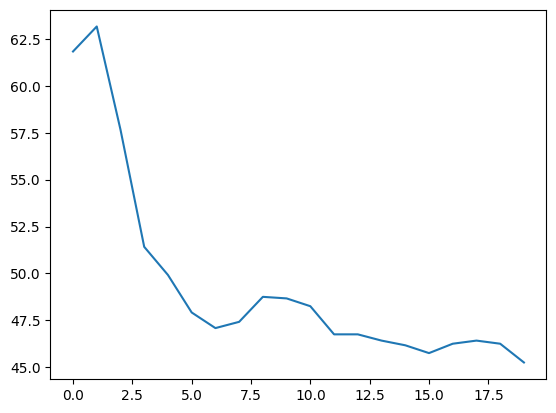

In [ ]:
# Initial weights and parameters
weights = [[[3, 3, 3], [2, 2, 2], [1, 1, 1]], [[1, 1, 1], [3, 3, 3], [-1, -1, 3]]]
decay_c = [[0.1, 0.2, 0.05], [0.1, 0.1, 0.1]]
fire_thresh = [[10, 5, 6], [11, 6, 3]]
cooldown_thresh = [[1, 1, 1], [1, 1, 1]]

# Layer initializations
l1 = Spike_Layer(3, weights[0], decay_c[0], fire_thresh[0], cooldown_thresh[0])
l1.initialize_neurons()
l2 = Spike_Layer(3, weights[1], decay_c[1], fire_thresh[1], cooldown_thresh[1])
l2.initialize_neurons()

connect_layer = Spike_Prop_Layer(l1, l2)
decision_layer = Output_Decision_Layer(l2)

# Potential tracking
potentials_1 = []
potentials_2 = []
potentials_3 = []

potentials_1_2 = []
potentials_2_2 = []
potentials_3_2 = []

# activation functions
input2 = []

loss_per_epoch = []
epoch = 20

for j in range(epoch):
    epoch_loss = 0
    for l in range(len(X_train)):
        potentials_1 = []
        potentials_2 = []
        potentials_3 = []

        potentials_1_2 = []
        potentials_2_2 = []
        potentials_3_2 = []

        # activation functions
        input2 = []

        for i in range(len(X_train[l])):
            l1.signal_prop(np.array([X_train[l][i]]))
            potentials_1.append(l1.neuron_list[0].potential)
            potentials_2.append(l1.neuron_list[1].potential)
            potentials_3.append(l1.neuron_list[2].potential)
            input2.append(connect_layer.output_collect())
            connect_layer.log_output_spike()

        for k in range(len(input2)):
            l2.signal_prop([input2[k]])
            potentials_1_2.append(l2.neuron_list[0].potential)
            potentials_2_2.append(l2.neuron_list[1].potential)
            potentials_3_2.append(l2.neuron_list[2].potential)
            decision_layer.log_output_spike()

        connect_layer.compute_percentage_spikes()
        decision_layer.compute_percentage_spikes()

        print(decision_layer.predict_output(), np.argmax(y_train[l]))
        print(decision_layer.output_count)

        epoch_loss += (Training_Changes([connect_layer], decision_layer, y_train[l]))

        connect_layer.freq_count = np.zeros(l1.num_neuron)
        decision_layer.output_count = np.zeros(l2.num_neuron)

        for neuron in l1.neuron_list:
            neuron.reset_state()

        for neuron in l2.neuron_list:
            neuron.reset_state()
    loss_per_epoch.append(epoch_loss)

x_s = np.arange(0,len(loss_per_epoch),1)

plt.plot(x_s,loss_per_epoch)

print(loss_per_epoch)

##------------------ To Do: -----------------##
'''
Fix the zero-spike branch in the hidden connection layer. Its new fallback refers to self.l1, but the class stores the input layer as self.Layer_in. When there are no hidden spikes, that branch will raise AttributeError. Use the stored layer reference there. Also, output_collect() uses the global l1 rather than the instance’s input layer; use the instance reference so this class behaves correctly outside this specific notebook setup.

Threshold may be going downwards over time and resulting in negative thresholds

Keep accuracy separate from loss. Your print now compares the predicted class to argmax(y_train[l]), which is the right comparison. Record whether that comparison is correct for each sample and report accuracy by epoch. Keep the spike-share value labeled as a diagnostic unless you replace it with a defined training objective. For ties or no output spikes, decide explicitly whether prediction should be “no prediction” or a deterministic fallback; currently predict_output() silently returns class 0.

'''
# Need to plot figures
# Need to generate diagrams for each point
